In [1]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.399375 0.507375 0.617500 0.711250 0.788000 0.850500 0.887750 0.920750
0.405000 0.517875 0.616250 0.706875 0.790500 0.845000 0.888875 0.919250
0.399000 0.513750 0.614750 0.702125 0.782625 0.844625 0.891500 0.921625
0.391250 0.514500 0.603125 0.716375 0.791625 0.850250 0.887625 0.923375
0.367000 0.491750 0.622750 0.723000 0.809375 0.866625 0.906000 0.937500
0.361250 0.494875 0.606625 0.726125 0.801625 0.876000 0.917250 0.944625
0.369000 0.485000 0.604250 0.721375 0.811125 0.870250 0.913500 0.940625
0.361250 0.493125 0.615875 0.725250 0.802625 0.875250 0.918500 0.940875
0.330625 0.480000 0.610250 0.732375 0.829000 0.894250 0.933875 0.954250
0.332625 0.475625 0.620625 0.733750 0.829375 0.888250 0.925625 0.953375
0.329500 0.470125 0.614375 0.726875 0.831625 0.889500 0.925875 0.956750
0.333000 0.475250 0.608125 0.735250 0.828125 0.890500 0.931125 0.951625
0.302250 0.448375 0.613875 0.744750 0.835250 0.903750 0.935125 0.962250
0.291000 0.457000 0.621125 0.754875 0.841125 0.907125 0.937375 0.958625
0.298000 0.448500 0.610125 0.746625 0.835375 0.907875 0.942500 0.960500
0.291375 0.452375 0.603625 0.742250 0.840125 0.906875 0.936250 0.961250 """
data_str2 = """ 0.397375 0.517000 0.613375 0.719250 0.790375 0.845000 0.885500 0.917250
0.404750 0.511250 0.616750 0.715625 0.786375 0.845125 0.885750 0.919250
0.404750 0.513625 0.608250 0.709000 0.790750 0.844250 0.888000 0.917250
0.400750 0.501250 0.615000 0.702375 0.784250 0.850250 0.898625 0.915625
0.363875 0.489875 0.625125 0.725500 0.804750 0.873625 0.913750 0.944375
0.352875 0.488250 0.616250 0.722250 0.807125 0.868375 0.911625 0.936500
0.353375 0.494750 0.617375 0.725375 0.813375 0.873500 0.915375 0.942750
0.367125 0.493250 0.610750 0.728375 0.804375 0.872375 0.910750 0.940500
0.327625 0.466250 0.609875 0.731125 0.825875 0.889625 0.926500 0.952125
0.323375 0.471000 0.605750 0.732875 0.825750 0.891250 0.928625 0.953000
0.327000 0.464500 0.622500 0.732000 0.824125 0.890125 0.927625 0.952250
0.325125 0.471125 0.609625 0.730875 0.822000 0.888125 0.930500 0.952500
0.299750 0.457750 0.608625 0.743500 0.844125 0.908125 0.939625 0.961000
0.300500 0.454875 0.604875 0.741875 0.843500 0.904250 0.935875 0.957250
0.295500 0.454625 0.618250 0.747875 0.840000 0.901750 0.942375 0.958000
0.304250 0.448125 0.617375 0.745875 0.845375 0.904625 0.943500 0.961625 """
data_str3 = """ 0.401500 0.517625 0.617625 0.705250 0.791125 0.849125 0.893125 0.923375
0.398875 0.505000 0.622375 0.708875 0.784000 0.857500 0.887750 0.920375
0.400875 0.510625 0.609000 0.712375 0.782375 0.846250 0.883875 0.926625
0.386375 0.503750 0.607875 0.720500 0.782250 0.848750 0.893875 0.919250
0.357750 0.486500 0.619000 0.726750 0.804125 0.871125 0.910375 0.941375
0.365000 0.495500 0.616125 0.721500 0.811750 0.869125 0.913125 0.938250
0.364875 0.491625 0.617250 0.724500 0.804125 0.873625 0.915625 0.940000
0.363875 0.489625 0.611000 0.717875 0.815500 0.875125 0.913750 0.939125
0.326875 0.473875 0.615625 0.735500 0.824000 0.889375 0.931000 0.954500
0.327125 0.465750 0.618250 0.729125 0.828000 0.887125 0.924375 0.951000
0.313750 0.474375 0.604625 0.725000 0.827625 0.894125 0.921750 0.948750
0.326250 0.484375 0.608625 0.728500 0.818375 0.889250 0.924375 0.953375
0.293000 0.460250 0.610125 0.741500 0.851000 0.906875 0.945750 0.961625
0.291250 0.440500 0.613750 0.736250 0.849375 0.899125 0.941375 0.961375
0.296875 0.450500 0.615250 0.746250 0.842750 0.907125 0.941375 0.959000
0.307875 0.453000 0.608125 0.741875 0.835375 0.900625 0.944750 0.956875 """
data_str4 = """ 0.399000 0.512875 0.620250 0.708125 0.790250 0.845250 0.892250 0.922375
0.396375 0.513500 0.618750 0.710375 0.790125 0.850875 0.886125 0.921750
0.406000 0.504125 0.616875 0.714750 0.787750 0.848750 0.886625 0.923625
0.407000 0.513750 0.618750 0.720875 0.783000 0.844125 0.888875 0.923000
0.369500 0.485625 0.609750 0.723750 0.807125 0.873875 0.914125 0.942625
0.349000 0.478375 0.616750 0.731500 0.811500 0.871875 0.909875 0.940125
0.362250 0.501625 0.605875 0.729875 0.800875 0.868125 0.913125 0.937125
0.358125 0.491250 0.620625 0.719250 0.808125 0.866875 0.908000 0.935250
0.324375 0.480250 0.606250 0.728000 0.824875 0.888375 0.926125 0.951125
0.335875 0.469375 0.612375 0.738875 0.825000 0.891250 0.926250 0.952500
0.330125 0.463125 0.612125 0.732500 0.821875 0.885000 0.930625 0.951500
0.329625 0.479000 0.605625 0.733500 0.826875 0.895125 0.928500 0.954250
0.292375 0.450500 0.605500 0.745250 0.846250 0.903000 0.940625 0.959250
0.295000 0.451875 0.607125 0.747375 0.836875 0.904000 0.938375 0.960875
0.295125 0.456250 0.609750 0.738625 0.835875 0.907125 0.941375 0.963750
0.290125 0.444625 0.613250 0.744875 0.836125 0.902500 0.945500 0.963125 """
data_str5 = """ 0.394875 0.510625 0.616250 0.713875 0.793250 0.846000 0.891875 0.923250
0.405500 0.513750 0.608250 0.708875 0.792000 0.845000 0.891250 0.917625
0.400125 0.504375 0.625875 0.713875 0.788875 0.843125 0.890375 0.917250
0.387500 0.509375 0.610000 0.709125 0.789750 0.850500 0.887250 0.920625
0.362125 0.488125 0.615250 0.715750 0.802625 0.867125 0.912625 0.942125
0.364750 0.490875 0.625125 0.714375 0.808375 0.861625 0.913375 0.938125
0.366875 0.479000 0.619125 0.721625 0.803750 0.870750 0.910125 0.935625
0.365625 0.491375 0.621625 0.720750 0.806125 0.867750 0.916875 0.938125
0.334875 0.471375 0.612875 0.733875 0.830000 0.885500 0.927375 0.952625
0.325625 0.476375 0.608625 0.734375 0.829000 0.888000 0.928875 0.948375
0.331125 0.470000 0.613125 0.725125 0.825875 0.890250 0.928750 0.950875
0.323625 0.467000 0.613000 0.729500 0.826125 0.889750 0.928500 0.952250
0.292500 0.456250 0.604750 0.747375 0.841000 0.899500 0.938250 0.963250
0.294875 0.462500 0.605250 0.750750 0.842375 0.906000 0.938750 0.960375
0.297875 0.447625 0.614750 0.743250 0.835250 0.902875 0.939875 0.958875
0.295375 0.455375 0.614125 0.743625 0.845750 0.904625 0.941500 0.959875 """
data_str6 = """ 0.403750 0.512500 0.615000 0.707875 0.788250 0.849750 0.891625 0.919000
0.402625 0.520375 0.619250 0.707750 0.789375 0.845750 0.883500 0.919000
0.401875 0.522125 0.615500 0.710625 0.783125 0.843250 0.890875 0.918125
0.394875 0.514500 0.621125 0.713875 0.789250 0.847250 0.891000 0.919750
0.359750 0.489250 0.616000 0.722125 0.801750 0.873250 0.911500 0.941125
0.364500 0.486375 0.614625 0.731125 0.801625 0.869750 0.911500 0.940500
0.369125 0.487625 0.614375 0.723000 0.808375 0.874375 0.911750 0.938500
0.360250 0.488500 0.622250 0.728375 0.804000 0.865875 0.913375 0.936375
0.322375 0.465875 0.604000 0.733250 0.835875 0.888375 0.930250 0.951500
0.330000 0.472375 0.618125 0.724625 0.821375 0.885000 0.925750 0.950625
0.334875 0.474500 0.610750 0.730375 0.829125 0.888000 0.933500 0.947750
0.325500 0.463250 0.609875 0.729500 0.822375 0.890625 0.928125 0.949000
0.303625 0.454875 0.603375 0.742000 0.842875 0.908625 0.944625 0.957750
0.295500 0.453625 0.605500 0.743750 0.840250 0.906000 0.944250 0.959000
0.297375 0.445375 0.603000 0.747750 0.848500 0.901875 0.938875 0.955375
0.299000 0.461125 0.609125 0.747375 0.833250 0.902125 0.936375 0.956625 """
data_str7 = """ 0.405750 0.510000 0.616125 0.710000 0.795375 0.853125 0.896250 0.921625
0.401875 0.520500 0.614250 0.706500 0.792125 0.848125 0.892875 0.925625
0.404000 0.508250 0.622625 0.709750 0.781125 0.852125 0.890000 0.927125
0.398125 0.513125 0.621125 0.709750 0.781875 0.846500 0.888750 0.917875
0.360375 0.496375 0.627000 0.728125 0.805000 0.875000 0.913500 0.939500
0.365625 0.494375 0.621375 0.723750 0.807500 0.873750 0.913250 0.938125
0.361875 0.494000 0.614375 0.721875 0.809375 0.877875 0.912000 0.939375
0.358750 0.492750 0.619875 0.721125 0.816125 0.876875 0.912000 0.941750
0.336875 0.464375 0.610750 0.727750 0.822750 0.885250 0.928625 0.955250
0.330875 0.467125 0.619250 0.728750 0.823000 0.889375 0.929625 0.953375
0.329875 0.473625 0.616000 0.742125 0.821000 0.887625 0.929000 0.948250
0.330375 0.480125 0.610500 0.727625 0.827000 0.885375 0.925375 0.952875
0.297625 0.446875 0.611000 0.738750 0.842000 0.897500 0.935000 0.961625
0.298375 0.456125 0.610375 0.738875 0.836125 0.902750 0.939500 0.962250
0.297250 0.454625 0.621000 0.738750 0.850000 0.906000 0.940875 0.961875
0.296125 0.451875 0.611500 0.739000 0.844625 0.908375 0.942000 0.961125 """
# data_str8 = """ 0.405750 0.510000 0.616125 0.710000 0.795375 0.853125 0.896250 0.921625
# 0.401875 0.520500 0.614250 0.706500 0.792125 0.848125 0.892875 0.925625
# 0.404000 0.508250 0.622625 0.709750 0.781125 0.852125 0.890000 0.927125
# 0.398125 0.513125 0.621125 0.709750 0.781875 0.846500 0.888750 0.917875
# 0.360375 0.496375 0.627000 0.728125 0.805000 0.875000 0.913500 0.939500
# 0.365625 0.494375 0.621375 0.723750 0.807500 0.873750 0.913250 0.938125
# 0.361875 0.494000 0.614375 0.721875 0.809375 0.877875 0.912000 0.939375
# 0.358750 0.492750 0.619875 0.721125 0.816125 0.876875 0.912000 0.941750
# 0.336875 0.464375 0.610750 0.727750 0.822750 0.885250 0.928625 0.955250
# 0.330875 0.467125 0.619250 0.728750 0.823000 0.889375 0.929625 0.953375
# 0.329875 0.473625 0.616000 0.742125 0.821000 0.887625 0.929000 0.948250
# 0.330375 0.480125 0.610500 0.727625 0.827000 0.885375 0.925375 0.952875
# 0.297625 0.446875 0.611000 0.738750 0.842000 0.897500 0.935000 0.961625
# 0.298375 0.456125 0.610375 0.738875 0.836125 0.902750 0.939500 0.962250
# 0.297250 0.454625 0.621000 0.738750 0.850000 0.906000 0.940875 0.961875
# 0.296125 0.451875 0.611500 0.739000 0.844625 0.908375 0.942000 0.961125 """
# data_str9 = """ 0.581800 0.592700 0.634300 0.644700 0.661500 0.676600 0.692000 0.723200
# 0.578100 0.615900 0.625000 0.638200 0.663700 0.687800 0.698800 0.715000
# 0.576900 0.597900 0.627000 0.643100 0.661500 0.676000 0.699200 0.715300
# 0.580700 0.601100 0.625200 0.635400 0.659300 0.681200 0.704400 0.719400
# 0.569000 0.597500 0.631100 0.639700 0.673100 0.689400 0.706300 0.727200
# 0.559900 0.595800 0.620700 0.641500 0.671300 0.689100 0.704900 0.728200
# 0.577400 0.589000 0.621500 0.648400 0.660000 0.689200 0.699900 0.723500
# 0.569200 0.595500 0.611200 0.643700 0.657000 0.679900 0.703100 0.725500
# 0.565100 0.596800 0.614100 0.645400 0.666300 0.690400 0.713700 0.729900
# 0.560600 0.581600 0.622800 0.648500 0.675400 0.692800 0.717600 0.739400
# 0.555300 0.591400 0.608400 0.646900 0.668200 0.693600 0.713100 0.737200
# 0.571400 0.593000 0.617600 0.640200 0.672000 0.692600 0.723700 0.730800
# 0.552200 0.587200 0.612500 0.650800 0.671600 0.702000 0.731700 0.755700
# 0.548400 0.594400 0.611500 0.649300 0.669400 0.704800 0.734800 0.746800
# 0.554800 0.586600 0.618000 0.638800 0.669200 0.695200 0.728200 0.754900
# 0.555800 0.584200 0.612800 0.646200 0.676600 0.696500 0.721600 0.747000 """
# data_str10= """ 0.582100 0.595400 0.628700 0.647900 0.665400 0.685800 0.700200 0.716700
# 0.582100 0.598800 0.626000 0.643700 0.662600 0.682900 0.702300 0.714100
# 0.581700 0.610100 0.624800 0.642000 0.663500 0.679400 0.693200 0.715200
# 0.573600 0.603900 0.619000 0.643000 0.658700 0.685200 0.694600 0.707500
# 0.576200 0.587000 0.618500 0.640500 0.657600 0.686500 0.713500 0.734000
# 0.569200 0.589900 0.619300 0.643200 0.661700 0.683900 0.704200 0.728400
# 0.572000 0.598300 0.615900 0.639100 0.660300 0.693700 0.707900 0.723900
# 0.572000 0.600200 0.623900 0.637500 0.667300 0.690600 0.708500 0.729300
# 0.567800 0.598900 0.617600 0.641100 0.666900 0.694900 0.721200 0.748300
# 0.560000 0.596700 0.615800 0.656900 0.679700 0.700000 0.723400 0.734700
# 0.557500 0.586400 0.619500 0.638600 0.666100 0.698500 0.706300 0.733900
# 0.568000 0.595300 0.617300 0.642700 0.669500 0.693600 0.710000 0.743100
# 0.555600 0.590700 0.620600 0.642300 0.666000 0.698100 0.720700 0.744300
# 0.552900 0.584100 0.618000 0.654800 0.679600 0.701200 0.725000 0.755500
# 0.563900 0.588700 0.612400 0.644800 0.671600 0.704000 0.732900 0.744200
# 0.554600 0.586200 0.609300 0.648800 0.671200 0.693400 0.727900 0.755300 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
run4 = np.loadtxt(StringIO(data_str4))
run5 = np.loadtxt(StringIO(data_str5))
run6 = np.loadtxt(StringIO(data_str6))
run7 = np.loadtxt(StringIO(data_str7))
# run8 = np.loadtxt(StringIO(data_str8))
# run9 = np.loadtxt(StringIO(data_str9))
# run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3, run4, run5, run6, run7]) #, run2, run3, run4, run5, run6, run7, run8, run9, run10

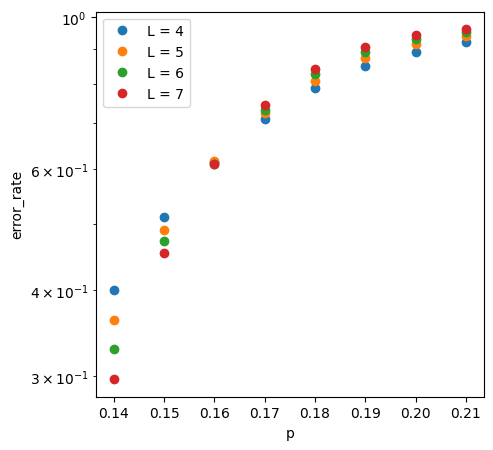

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [3]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21]), 4)

L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 8000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [4]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.16024532   1.56197678   0.62030314   3.92184157 -11.47885403]
Parameter standard deviations: [6.93616632e-04 5.66371402e-02 8.10649938e-03 1.65997858e-01
 9.21472681e-01]


np.float64(32.739471882496645)

In [5]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.16013044   1.56836877   0.61978105   3.94974532 -11.90905791
   1.8030265 ]
Parameter standard deviations: [7.06815591e-04 5.80491132e-02 8.15064483e-03 1.72335015e-01
 1.13628718e+00 2.44010335e+00]


np.float64(32.780844525742964)

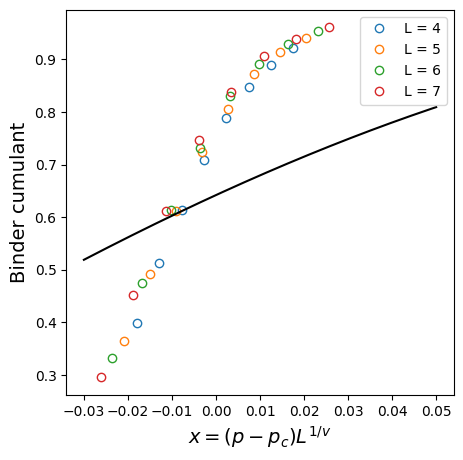

In [11]:
pc = 0.16107576
nu = 1.48950467
A = 0.6419381
B = 3.83773775
C = -9.16936443
D =  -14.9870922

p = [0.154, 0.156, 0.158, 0.16, 0.162, 0.164, 0.166, 0.168]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.03, 0.05, 1000)
y_data = A + B*x_data + C*(x_data**2) +D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()